# Baseline Models
TF-IDF + Logistic Regression, TF-IDF + SVM, Cross-dataset transfer


**Note**: All the results will be saved and read on/from the local Google Drive in `StanceProject` directory.

In [ ]:
!pip install -q scikit-learn pandas matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/StanceProject'

Mounted at /content/drive
Drive mounted. Project: /content/drive/MyDrive/StanceProject


In [ ]:
# load all libraries
import pandas as pd
import numpy as np
import re, copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

Libraries loaded.


## Load data


In [ ]:
cvs = pd.read_csv(f'{PROJECT}/data/processed/covid_vax_stance.csv')
te  = pd.read_csv(f'{PROJECT}/data/processed/tweeteval_stance.csv')
print('covid-vax-stance:', cvs.shape, ', labels:', cvs['label'].unique().tolist())
print('TweetEval stance:', te.shape,  ', labels:', te['label'].unique().tolist())

covid-vax-stance: (3139, 4) | labels: ['Neutral', 'ProVax', 'AntiVax']
TweetEval stance: (933, 6) | labels: ['against', 'none', 'favor']


## Preprocessing

In [ ]:
def preprocess(text):
    text = str(text)
    text = re.sub(r'http\S+', 'URL', text)
    text = re.sub(r'@\w+', 'USER', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s!?.,]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

cvs['clean'] = cvs['text'].apply(preprocess)
te['clean'] = te['text'].apply(preprocess)

## Splits

In [ ]:
def get_splits(df):
    if 'split' in df.columns and df['split'].nunique() > 1:
        return df[df['split'] == 'train'].copy(), df[df['split'].isin(['test','validation'])].copy()
    return train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

cvs_tr, cvs_te = get_splits(cvs)
te_tr, te_te = get_splits(te)
print(f'CVS: train={len(cvs_tr)} test={len(cvs_te)}')
print(f'TE: train={len(te_tr)} test={len(te_te)}')

CVS  train=2511  test=628
TE   train=587   test=346


## Models & evaluation

In [ ]:
def make_pipelines():
    tfidf = dict(ngram_range=(1,2), max_features=50000, sublinear_tf=True)
    return {
        'LR': Pipeline([('tfidf', TfidfVectorizer(**tfidf)), ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))]),
        'SVM': Pipeline([('tfidf', TfidfVectorizer(**tfidf)), ('clf', LinearSVC(max_iter=2000, C=1.0, random_state=42))]),
    }

all_results = []

def evaluate(name, model, X_tr, y_tr, X_te, y_te, ds_name):
    model.fit(X_tr, y_tr)
    y_pred   = model.predict(X_te)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    print(f'\n{ds_name} | {name} | macro-F1={macro_f1:.3f}')
    print(classification_report(y_te, y_pred, digits=3))

    labels = sorted(pd.Series(y_te).unique())
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred, labels=labels), display_labels=labels).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{ds_name} — {name}  (F1={macro_f1:.3f})')
    plt.tight_layout()
    safe = ds_name.lower().replace(' ','-')
    plt.savefig(f'{PROJECT}/plots/cm_{safe}_{name.lower()}.png', bbox_inches='tight')
    plt.show()

    all_results.append({'dataset': ds_name, 'model': name, 'macro_f1': round(macro_f1, 4)})

### Train & evaluate: covid-vax-stance


covid-vax-stance | LR | macro-F1=0.396
              precision    recall  f1-score   support

     AntiVax      0.000     0.000     0.000        98
     Neutral      0.556     0.521     0.538       257
      ProVax      0.553     0.784     0.648       273

    accuracy                          0.554       628
   macro avg      0.370     0.435     0.396       628
weighted avg      0.468     0.554     0.502       628



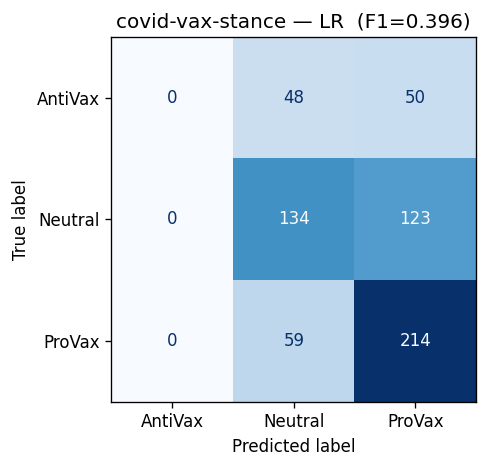


covid-vax-stance | SVM | macro-F1=0.493
              precision    recall  f1-score   support

     AntiVax      0.514     0.194     0.281        98
     Neutral      0.584     0.525     0.553       257
      ProVax      0.567     0.747     0.645       273

    accuracy                          0.570       628
   macro avg      0.555     0.489     0.493       628
weighted avg      0.566     0.570     0.551       628



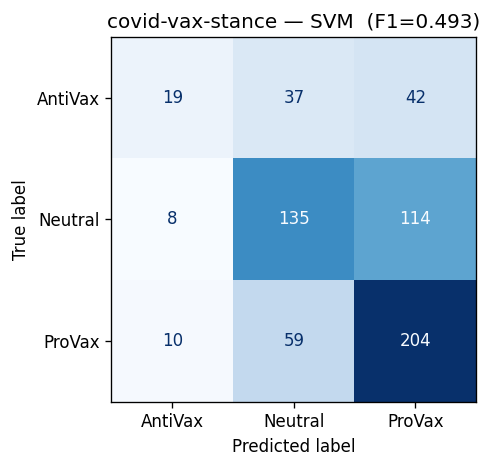

In [ ]:
for name, pipe in make_pipelines().items():
    evaluate(name, pipe, cvs_tr['clean'], cvs_tr['label'], cvs_te['clean'], cvs_te['label'], 'covid-vax-stance')

### Train & evaluate: TweetEval


TweetEval-stance | LR | macro-F1=0.372
              precision    recall  f1-score   support

     against      0.666     0.973     0.791       225
       favor      1.000     0.121     0.215        58
        none      0.400     0.063     0.110        63

    accuracy                          0.665       346
   macro avg      0.689     0.386     0.372       346
weighted avg      0.673     0.665     0.570       346



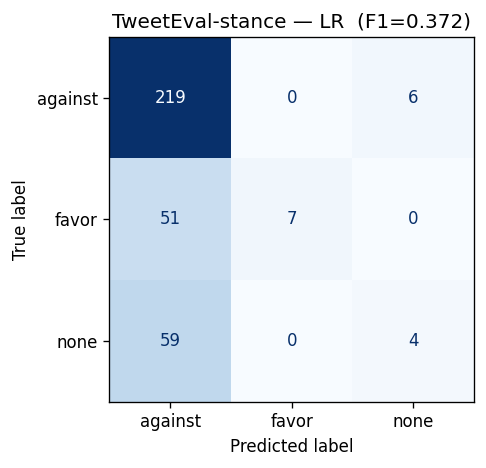


TweetEval-stance | SVM | macro-F1=0.511
              precision    recall  f1-score   support

     against      0.720     0.822     0.768       225
       favor      0.500     0.362     0.420        58
        none      0.404     0.302     0.345        63

    accuracy                          0.650       346
   macro avg      0.541     0.495     0.511       346
weighted avg      0.626     0.650     0.632       346



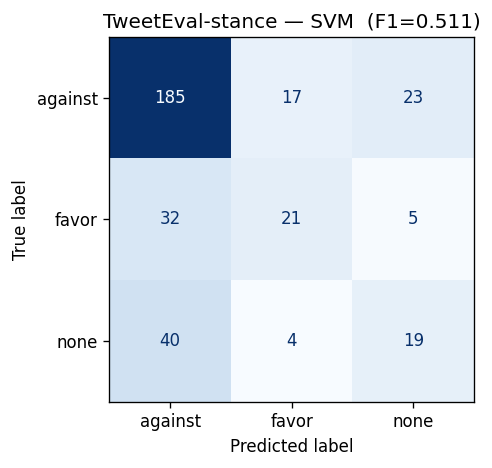

In [ ]:
for name, pipe in make_pipelines().items():
    evaluate(name, pipe, te_tr['clean'], te_tr['label'], te_te['clean'], te_te['label'], 'TweetEval-stance')

## Cross-dataset transfer

Train on one domain, test on the other (unified labels, no re-training on target).

In [ ]:
for name, pipe in make_pipelines().items():
    p = copy.deepcopy(pipe)
    p.fit(cvs_tr['clean'], cvs_tr['label_unified'])
    y_pred = p.predict(te_te['clean'])
    f1 = f1_score(te_te['label_unified'], y_pred, average='macro')
    print(f'{name} CVS->TE macro-F1={f1:.3f}')
    all_results.append({'dataset': 'CVS->TweetEval (transfer)', 'model': name, 'macro_f1': round(f1, 4)})

for name, pipe in make_pipelines().items():
    p = copy.deepcopy(pipe)
    p.fit(te_tr['clean'], te_tr['label_unified'])
    y_pred = p.predict(cvs_te['clean'])
    f1 = f1_score(cvs_te['label_unified'], y_pred, average='macro')
    print(f'{name} TE->CVS macro-F1={f1:.3f}')
    all_results.append({'dataset': 'TweetEval->CVS (transfer)', 'model': name, 'macro_f1': round(f1, 4)})

=== Cross-domain transfer ===

LR  CVS→TE   macro-F1=0.182
SVM  CVS→TE   macro-F1=0.229
LR  TE→CVS   macro-F1=0.120
SVM  TE→CVS   macro-F1=0.193


## Save results

In [ ]:
results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{PROJECT}/results/baseline_results.csv', index=False)

pivot = results_df[~results_df['dataset'].str.contains('transfer')].pivot_table(index='model', columns='dataset', values='macro_f1')
print(pivot.to_string())

Saved baseline_results.csv to Drive.

dataset  TweetEval-stance  covid-vax-stance
model                                      
LR                 0.3719            0.3955
SVM                0.5110            0.4931

Run 03_bertweet_finetuning.ipynb next (GPU required).
